# [Data Preparation](https://rhindottire.github.io/Data-Mining/dataProcess.html#data-preparation)

This notebook turns the raw corpus into the model-ready representations the
preprocessing task requires: a cleaned token stream, the TF-IDF dataset, and
its principal-component summary, and the sentence corpus for the skip-gram
arm of the modeling stage. Every rule is traced to a finding from the
Data Understanding stage, every transformation reports before-and-after
evidence, and the run reads only the stored CSV — the single network action is
fetching the public POS tagger model on its first execution.

## 1. Data Verification

Step 1 of the preprocessing list is exploration, which lives on the Data
Understanding page. This section only re-verifies the stored corpus against
those findings before any change, and no row is dropped anywhere on this page.

In [1]:
import json
import re
import unicodedata
from collections import Counter
from pathlib import Path

import langid
import pandas as pd
from indoNLP.preprocessing import replace_slang
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

DATA_DIR = Path("..") / ".." / "data" / "Web-Mining"
OUT_DIR = DATA_DIR / "crisp-dm"
OUT_DIR.mkdir(exist_ok=True)

raw = pd.read_csv(DATA_DIR / "crawling_detik.csv")
host = raw["url"].str.extract(r"https?://([a-z]+)\.detik\.com")[0]
pd.Series(
    {
        "rows": len(raw),
        "columns": raw.shape[1],
        "missing cells": int(raw.isna().sum().sum()),
        "duplicate rows": int(raw.duplicated().sum()),
        "duplicate urls": int(raw["url"].duplicated().sum()),
        "sequential ids": raw["id"].tolist() == list(range(1, len(raw) + 1)),
        "label versus host mismatch": int((host != raw["label"]).sum()),
        "label counts": str(raw["label"].value_counts().to_dict()),
    },
    name="value",
)

rows                                                     200
columns                                                    4
missing cells                                              0
duplicate rows                                             0
duplicate urls                                             0
sequential ids                                          True
label versus host mismatch                                 0
label counts                  {'sport': 100, 'finance': 100}
Name: value, dtype: object

Sel ini memuat pustaka, membaca CSV yang tersimpan, dan memeriksa struktur
terhadap temuan tahap pengumpulan: 200 baris, tanpa nilai kosong, tanpa
duplikat baris maupun URL, id berurutan, dan host URL cocok dengan label.
Tidak ada baris yang dibuang; halaman ini tidak menulis ulang data crawl dan
tidak mengirim permintaan jaringan apa pun.

## 2. Text Cleaning

Step 2 of the list in five passes: encoding normalization, format artifacts,
whitespace collapse, number decisions, and the short-token filter. The
sub-sections mirror the pipeline order of the Data Understanding page, and
every table reports counts before and after on the stored 200 articles.

### Encoding Normalization

In [2]:
PUNCT_MAP = {
    "\u2011": "-",
    "\u2013": "-",
    "\u2014": "-",
    "\u2026": "...",
    "\u2018": "'",
    "\u2019": "'",
    "\u201c": '"',
    "\u201d": '"',
}


def ascii_normalize(value):
    decomposed = unicodedata.normalize("NFD", value)
    unaccented = "".join(ch for ch in decomposed if not unicodedata.combining(ch))
    for bad, good in PUNCT_MAP.items():
        unaccented = unaccented.replace(bad, good)
    return "".join(ch for ch in unaccented if ord(ch) < 128)


text = raw["isi_berita"].map(ascii_normalize)
ascii_docs_before = int(raw["isi_berita"].map(lambda t: any(ord(c) > 127 for c in t)).sum())
ascii_docs_after = int(text.map(lambda t: any(ord(c) > 127 for c in t)).sum())
glyphs_before = len({ch for t in raw["isi_berita"] for ch in t if ord(ch) > 127})
pd.DataFrame(
    [
        {
            "metric": "docs with non-ASCII characters",
            "before": ascii_docs_before,
            "after": ascii_docs_after,
        },
        {
            "metric": "distinct non-ASCII glyphs",
            "before": glyphs_before,
            "after": len({ch for t in text for ch in t if ord(ch) > 127}),
        },
        {
            "metric": "docs with decomposable accents",
            "before": int(raw["isi_berita"].map(lambda t: len(unicodedata.normalize("NFD", t)) > len(t)).sum()),
            "after": int(text.map(lambda t: len(unicodedata.normalize("NFD", t)) > len(t)).sum()),
        },
    ]
)

,metric,before,after
0,docs with non-ASCII characters,6,0
1,distinct non-ASCII glyphs,8,0
2,docs with decomposable accents,3,0


Normalisasi encoding menguraikan aksen lewat NFD seperti temuan karakter
menetapkan (6 dokumen dengan 8 glyph di luar ASCII dan 4 glyph beraksen),
lalu membuang glyph simbol yang tersisa bersama tanda baca. Kapitalisasi asli
teks dipertahankan karena perlindungan nama nanti membaca huruf besar dari
teks apa adanya.

### Format Artifacts

In [3]:
ARTIFACTS = {
    "table pipes": r"\|[^|\n]*\|",
    "list or heading markers": r"(?m)^\s*[-*]\s|^#{1,6}\s",
    "mentions": r"@\w+",
    "embedded urls": r"https?://\S+|www\.\S+",
}


def docs_matching(series, pattern):
    return int(series.map(lambda t: bool(re.search(pattern, t))).sum())


before_counts = {name: docs_matching(text, pat) for name, pat in ARTIFACTS.items()}
cleaned = text.map(lambda t: re.sub(r"\|", " ", t))
for pattern in ARTIFACTS.values():
    cleaned = cleaned.map(lambda t, p=pattern: re.sub(p, " ", t))
after_counts = {name: docs_matching(cleaned, pat) for name, pat in ARTIFACTS.items()}
text = cleaned
pd.DataFrame(
    [
        {"artifact": name, "docs before": before_counts[name], "docs after": after_counts[name]}
        for name in ARTIFACTS
    ]
)

,artifact,docs before,docs after
0,table pipes,37,0
1,list or heading markers,17,0
2,mentions,4,0
3,embedded urls,2,0


Artefak format dihitung per kelas sebelum dan sesudah pemotongan, merujuk
temuan artefak: 37 dokumen menyisakan garis tabel, 4 mention, dan 2 tautan
persis seperti hitungan teks mentah, sementara sisipan list atau heading
terbaca 17 dokumen setelah normalisasi ASCII membuka penanda garis bertype
non-ASCII yang belum masuk hitungan temuan (16 dokumen). Pemotongan berjalan
pada teks yang masih multiline supaya penanda baris terdeteksi oleh pola
berjajar; pelipatan spasi menyusul di sel berikutnya.

### Whitespace Collapse

In [4]:
line_break_docs = int(text.map(lambda t: "\n" in t).sum())
space_run_docs = int(text.map(lambda t: bool(re.search(r" {2,}", t))).sum())
chars_before = int(text.str.len().sum())
collapsed = text.map(lambda t: re.sub(r"\s+", " ", t).strip())
text = collapsed
pd.DataFrame(
    [
        {
            "metric": "docs with line breaks",
            "before": line_break_docs,
            "after": int(text.map(lambda t: "\n" in t).sum()),
        },
        {
            "metric": "docs with repeated spaces",
            "before": space_run_docs,
            "after": int(text.map(lambda t: bool(re.search(r" {2,}", t))).sum()),
        },
        {
            "metric": "total characters",
            "before": chars_before,
            "after": int(text.str.len().sum()),
        },
    ]
)

,metric,before,after
0,docs with line breaks,200,0
1,docs with repeated spaces,41,0
2,total characters,538307,537514


Pemisah baris ada di seluruh 200 dokumen seperti temuan whitespace,
sedangkan ruang beruntun kini terbaca pada 41 dokumen: hitungan teks mentah di
temuan hanya satu, lalu pemotongan artefak pada sel sebelumnya membuka jarak
spasi baru di banyak dokumen. Sel ini melipat seluruh teks menjadi satu baris
spasi tunggal sehingga sisa ruang beruntun nol, dan jumlah karakter yang
terbuang terbaca pada baris terakhir tabel.

### Number Decisions

In [5]:
token_stream = text.map(lambda t: re.findall(r"[A-Za-z0-9]+(?:-[A-Za-z0-9]+)*", t))
date_spans = text.str.findall(r"\d{1,2}/\d{1,2}/\d{4}")


def count_matching(tokens, predicate):
    return sum(1 for tok in tokens if predicate(tok))


def docs_matching_tokens(tokens, predicate):
    return sum(1 for tokens_doc in tokens if any(predicate(tok) for tok in tokens_doc))


def context_for(token):
    for value in text:
        m = re.search(rf"\b{re.escape(token)}\b", value)
        if m:
            return value[max(0, m.start() - 35) : m.end() + 35].replace("\n", " ")
    return "none"


NUMBER_CLASSES = [
    ("pure digits", lambda t: t.isdigit(), "drop"),
    ("score composites", lambda t: bool(re.fullmatch(r"\d+[xX]\d+", t)), "keep intact"),
    ("roman numerals", lambda t: bool(re.fullmatch(r"[ivxl]{2,}", t.lower())), "keep intact"),
    ("hyphen numerics", lambda t: bool(re.fullmatch(r"\d+-\d+|[a-zA-Z]+-\d+", t)), "drop"),
    ("currency amounts", lambda t: bool(re.fullmatch(r"[Rr][Pp]\d+", t)), "keep currency symbol only"),
]
rows = []
for name, predicate, decision in NUMBER_CLASSES:
    matched = [tok for tokens_doc in token_stream for tok in tokens_doc if predicate(tok)]
    top = Counter(matched).most_common(1)
    rows.append(
        {
            "class": name,
            "occurrences": len(matched),
            "docs": docs_matching_tokens(token_stream, predicate),
            "examples": ", ".join(w for w, _ in Counter(matched).most_common(3)) or "none",
            "context": context_for(top[0][0]) if top else "none",
            "decision": decision,
        }
    )
date_flat = [span for group in date_spans for span in group]
rows.append(
    {
        "class": "date fragments",
        "occurrences": len(date_flat),
        "docs": sum(1 for group in date_spans if group),
        "examples": ", ".join(sorted(set(date_flat))[:3]) or "none",
        "context": context_for(date_flat[0]) if date_flat else "none",
        "decision": "drop",
    }
)
pd.DataFrame(rows)

,class,occurrences,docs,examples,context,decision
0,pure digits,3838,200,"2026, 1, 3","lam keterangannya, pada Jumat (7/8/2026). Dala...",drop
1,score composites,85,15,"3x3, 5x5, 4x4",isi Indonesia untuk meloloskan tim 3x3 ke Olim...,keep intact
2,roman numerals,66,21,"IV, II, III",kesempatan yang sama Wakil Rektor IV Universi...,keep intact
3,hyphen numerics,322,98,"U-18, 1-0, ke-23",utri Indonesia lolos ke Piala Asia U-18 2026. ...,drop
4,currency amounts,72,6,"Rp5, Rp117, Rp100","kerugian lingkungan hidup sebesar Rp5,30 tril...",keep currency symbol only
5,date fragments,164,142,"1/8/2026, 1/9/2026, 10/1/2025","i dalam keterangannya, pada Jumat (7/8/2026). ...",drop


Tabel keputusan kelas angka dibentuk dari korpus pada saat eksekusi:
frekuensi, jumlah dokumen, contoh token, dan jendela konteks tiap kelas.
Aturannya mengikuti rangkuman tahap pemahaman data — angka tidak dihitung
sebagai term, sedangkan komposit skor, simbol mata uang, dan angka Romawi
dipertahankan utuh; kode yang memuat angka dibuang beserta angkanya.

In [6]:
date_spans_removed = sum(len(re.findall(r"\d{1,2}/\d{1,2}/\d{4}", t)) for t in text)
rp_before = sum(len(re.findall(r"(?i)\b[Rr][Pp]\d+", t)) for t in text)
hyphen_removed = sum(len(re.findall(r"(?i)\b[a-zA-Z]+-\d+\b", t)) for t in text)
text = text.map(lambda t: re.sub(r"\d{1,2}/\d{1,2}/\d{4}", " ", t))
text = text.map(lambda t: re.sub(r"(?i)\b(rp)\d+", r"\1", t))
text = text.map(lambda t: re.sub(r"(?i)\b[a-zA-Z]+-\d+\b", " ", t))
tokens = text.map(lambda t: re.findall(r"[A-Za-z0-9]+(?:-[A-Za-z0-9]+)*", t))
pd.Series(
    {
        "date fragments removed": date_spans_removed,
        "currency amounts shortened to rp": rp_before,
        "hyphen numerics removed": hyphen_removed,
        "tokens after text rules": sum(map(len, tokens)),
        "score composites present": sum(
            1 for doc in tokens for tok in doc if re.fullmatch(r"\d+[xX]\d+", tok)
        ),
    },
    name="value",
)

date fragments removed                164
currency amounts shortened to rp       72
hyphen numerics removed                55
tokens after text rules             74961
score composites present               85
Name: value, dtype: int64

Aturan tingkat teks diterapkan lebih dulu: potongan tanggal dibuang, nominal
rupiah dipangkas menjadi simbol `rp`, dan kode ber-angka dibuang; tokenisasi
memecah pada batas kata sehingga komposit skor tetap menjadi satu token utuh
dan tidak pernah menyisakan residu seperti `x`. Jumlah sebelum-sesudah tiap
aturan terbaca dari keluaran sel ini.

### Short Token Filter

In [7]:
single_chars = Counter(tok for doc in tokens for tok in doc if len(tok) == 1)
short_twos = Counter(tok for doc in tokens for tok in doc if len(tok) == 2)
digit_tokens = Counter(tok for doc in tokens for tok in doc if any(ch.isdigit() for ch in tok))
pd.DataFrame(
    [
        {
            "class": "single-character tokens",
            "occurrences": sum(single_chars.values()),
            "examples": ", ".join(w for w, _ in single_chars.most_common(5)),
            "decision": "drop",
        },
        {
            "class": "two-character tokens",
            "occurrences": sum(short_twos.values()),
            "examples": ", ".join(w for w, _ in short_twos.most_common(5)),
            "decision": "keep",
        },
        {
            "class": "tokens containing digits",
            "occurrences": sum(digit_tokens.values()),
            "examples": ", ".join(w for w, _ in digit_tokens.most_common(5)),
            "decision": "drop unless score composite",
        },
    ]
)

,class,occurrences,examples,decision
0,single-character tokens,1143,"1, 5, 2, 6, 3",drop
1,two-character tokens,3804,"di, Rp, ke, Ia, Di",keep
2,tokens containing digits,3857,"2026, 1, 000, 5, 2",drop unless score composite


Cacahan residu token sebelum penyaringan membandingkan tiga kelas token
dengan temuan tahap pemahaman data: pembersihan naif menyisakan 425 token
satu huruf dan 3303 token dua huruf atau kurang, dan justru di sana terdapat
kata berimbuh yang sah seperti `di` (1436), `rp` (285), dan `ke` (260).
Keputusan diambil per kelas, bukan memotong panjang token secara buta.

In [8]:
tokens_before_filter = sum(map(len, tokens))
kept_tokens = []
dropped_single = 0
dropped_digit = 0
for doc in tokens:
    kept = []
    for tok in doc:
        if re.fullmatch(r"\d+[xX]\d+", tok):
            kept.append(tok)
        elif any(ch.isdigit() for ch in tok):
            dropped_digit += 1
        elif len(tok) < 2:
            dropped_single += 1
        else:
            kept.append(tok)
    kept_tokens.append(kept)
tokens = kept_tokens
pd.Series(
    {
        "tokens before filter": tokens_before_filter,
        "dropped single-character": dropped_single,
        "dropped digit-bearing": dropped_digit,
        "tokens after filter": sum(map(len, tokens)),
    },
    name="value",
)

tokens before filter        74961
dropped single-character      218
dropped digit-bearing        3772
tokens after filter         70971
Name: value, dtype: int64

Penyaringan membuang token satu huruf dan token yang memuat angka, dengan
pengecualian komposit skor yang dipertahankan utuh sehingga residu `x` tidak
pernah terbentuk. Keluaran menampilkan jumlah token sebelum penyaringan dan
rincian per alasan pembuangan, bukti sebelum-sesudah untuk dua kelas temuan
residu tadi.

## 10. POS Tagging

Step 10 runs here, before step 5, because the annotation must still see
function words as context; the note list fixes this position explicitly. The
public tagger model is the only network action of this page.

In [9]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")
import transformers
from transformers import AutoModelForTokenClassification, AutoTokenizer
from transformers import pipeline as hf_pipeline

transformers.logging.set_verbosity_error()
TAGGER = "w11wo/indonesian-roberta-base-posp-tagger"
tag_tokenizer = AutoTokenizer.from_pretrained(TAGGER)
tag_tokenizer.model_max_length = 512
tag_model = AutoModelForTokenClassification.from_pretrained(TAGGER)
tagger = hf_pipeline(
    "token-classification",
    model=tag_model,
    tokenizer=tag_tokenizer,
    aggregation_strategy="simple",
    device=-1,
)
doc_sentences = [re.split(r"(?<=[.!?])\s+", t) for t in text]
flat_sentences = [s for group in doc_sentences for s in group if s.strip()]
tagged = tagger(flat_sentences, batch_size=16, stride=64)
pos_by_doc = []
cursor = 0
for group in doc_sentences:
    annotated = []
    for sentence in group:
        if sentence.strip():
            annotated.extend(
                (chunk["word"].strip(), chunk["entity_group"]) for chunk in tagged[cursor]
            )
            cursor += 1
    pos_by_doc.append(annotated)
tag_counts = Counter(tag for annotated in pos_by_doc for _, tag in annotated)
n_tagged = sum(tag_counts.values())
pd.Series(tag_counts, name="tokens").sort_values(ascending=False)

NNP    27735
NNO    21463
SYM    11589
NUM     7309
PPO     7007
VBT     4038
VBI     2829
ADJ     2617
ADV     2594
CCN     2327
VBP     1681
PRR     1522
PRN     1288
ART     1223
CSN     1141
ADK      906
VBL      740
KUA      550
NEG      427
$$$      276
PAR      245
UNS      212
VBE      177
PRI      130
PRK       22
INT        3
Name: tokens, dtype: int64

POS tagging berjalan sebelum penghapusan stopword sehingga kata fungsi masih
ada sebagai konteks, sesuai urutan yang ditetapkan untuk tugas ini. Model
tagger publik diambil sekali saat pertama dijalankan — satu-satunya akses
jaringan halaman ini — lalu anotasi disimpan per dokumen sebagai kolom
pendamping yang tidak pernah masuk ke representasi TF-IDF. Distribusi tag pada
keluaran memperlihatkan komposisi kategori kata korpus berita.

## 3. Language Policy

Step 3 decides the foreign-language handling per sentence and per token,
preserving everything whose translation would change the context; the
zero-translation decision is part of the evidence table.

In [10]:
sentence_langs = Counter()
for value in text:
    for sentence in re.split(r"(?<=[.!?])\s+", value):
        sentence = sentence.strip()
        if len(sentence.split()) < 4:
            continue
        lang, _ = langid.classify(sentence)
        sentence_langs[lang] += 1
top_vocab = Counter(tok for doc in tokens for tok in doc).most_common(400)
en_labels = sum(1 for word, _ in top_vocab if langid.classify(word)[0] == "en")
non_id = sum(n for lang, n in sentence_langs.items() if lang not in ("id", "ms"))
pd.DataFrame(
    [
        {"evidence": "sentences classified", "value": sum(sentence_langs.values())},
        {"evidence": "sentences outside id/ms", "value": non_id},
        {"evidence": "top-400 tokens labelled en", "value": en_labels},
        {"evidence": "tokens translated", "value": 0},
    ]
)

,evidence,value
0,sentences classified,4314
1,sentences outside id/ms,109
2,top-400 tokens labelled en,253
3,tokens translated,0


Kebijakan bahasa asing berpijak pada temuan bahasa — 4316 kalimat, 112 di
luar id/ms, dan 229 dari 400 token teratas salah dilabeli `en` — yang kini
dihitung ulang pada teks bersih sehingga angka mutakhirnya terbaca di tabel.
Karena label per token tidak dapat dipercaya untuk memutuskan terjemahan,
keputusannya preserve-first: nol token diterjemahkan, dan angka nol itu
sendiri dicatat sebagai baris terakhir tabel sebagai bagian dari tabel
keputusan.

## 4. Slang Normalization

Step 4 canonicalizes non-standard words while protecting names and acronyms;
candidate and dictionary evidence are shown before the replacement is applied.

### Name Candidates

In [11]:
lower_docs = Counter()
cap_mid_docs = Counter()
for value in raw["isi_berita"]:
    lower_docs.update({w.lower() for w in re.findall(r"\b[a-z]{3,}\b", value)})
    cap_mid_docs.update({w.lower() for w in re.findall(r"(?<![.!?]\s)\b[A-Z][a-z]{2,}\b", value)})
cap_mid_protected = {w for w, n in cap_mid_docs.items() if n >= 2}
acronym_docs = Counter()
for doc in tokens:
    acronym_docs.update({tok for tok in doc if tok.isupper() and len(tok) >= 2})
acronym_protected = {w.lower() for w, n in acronym_docs.items() if n >= 2}
protected = cap_mid_protected | acronym_protected
mixed_candidates = sorted(cap_mid_protected, key=lambda w: -cap_mid_docs[w])
rows = [
    {"candidate": w, "kind": "capitalized mid", "docs": cap_mid_docs[w]} for w in mixed_candidates[:12]
]
rows += [
    {"candidate": w.lower(), "kind": "all-caps acronym", "docs": n}
    for w, n in acronym_docs.most_common(4)
    if n >= 2
]
pd.DataFrame(rows)

,candidate,kind,docs
0,indonesia,capitalized mid,130
1,jakarta,capitalized mid,108
2,kamis,capitalized mid,53
3,basketball,capitalized mid,49
4,kami,capitalized mid,47
5,menteri,capitalized mid,46
6,selasa,capitalized mid,44
7,pusat,capitalized mid,39
8,pelita,capitalized mid,38
9,league,capitalized mid,38


Kandidat nama diambil dari token yang kapital di tengah kalimat pada teks
asli dengan minimal dua dokumen, ditambah akronim huruf besar yang terlihat
di token sebelum tahap pengecilan huruf. Jumlah kandidatnya berjejak dengan
temuan 1168 kandidat kapital-tengah. Token yang masuk daftar perlindungan ini
tidak boleh dinormalisasi slang maupun di-stem.

### Slang Replacement

In [12]:
tokens = [[tok.lower() for tok in doc] for doc in tokens]
slang_hits = Counter()
for doc in tokens:
    for tok in doc:
        if replace_slang(tok) != tok:
            slang_hits[tok] += 1
pd.DataFrame(
    [
        {
            "token": word,
            "occurrences": n,
            "protected_name": word in protected,
            "dictionary_mapping": replace_slang(word),
        }
        for word, n in slang_hits.most_common(12)
    ]
)

,token,occurrences,protected_name,dictionary_mapping
0,nggak,36,True,enggak
1,mbg,34,True,mbak
2,sma,25,True,sama
3,pass,13,True,pas
4,usa,10,False,usah
5,to,10,False,tapi
6,gt,10,False,begitu
7,do,9,False,di
8,minta,9,True,meminta
9,gitu,9,False,begitu


Kamus slang dijalankan pada token yang sudah dikecilkan hurufnya; tabel
memunculkan frekuensi, padanan kamus, dan penanda token yang terlindungi.
Temuan slang menjelaskan kenapa penggantian tidak boleh buta: dari 76 token
dan 563 kemunculan pada pembersihan naif, `nggak` (36) adalah slang sungguhan
sementara `sma` dan `mbg` kebetulan ada di kamus — kasus bentrok nama tampil
langsung di kolom `protected_name`; sisa kandidat seperti `x` dan `u` sudah
gugur di penyaringan token satu huruf sehingga tidak muncul di tabel.

In [13]:
tokens_preslang = [list(doc) for doc in tokens]
replaced = 0
protected_seen = 0
normalized = []
for doc in tokens:
    out = []
    for tok in doc:
        if tok in protected:
            protected_seen += 1
            out.append(tok)
        elif replace_slang(tok) != tok:
            out.append(replace_slang(tok))
            replaced += 1
        else:
            out.append(tok)
    normalized.append(out)
tokens = normalized
pd.Series(
    {
        "slang occurrences normalized": replaced,
        "protected token occurrences kept": protected_seen,
        "total tokens": sum(map(len, tokens)),
    },
    name="value",
)

slang occurrences normalized          161
protected token occurrences kept    35654
total tokens                        70971
Name: value, dtype: int64

Normalisasi slang hanya dijalankan pada token di luar daftar perlindungan;
token nama dan akronim dilewatkan apa adanya. Keluaran merangkum berapa kali
pemetaan kamus benar-benar diterapkan dan berapa kali token terlindungi
ditemui — dua angka yang menutup tahap normalisasi dengan bukti sebelum
lanjut ke stopword.

## 5. Stopword Removal

Step 5 drops Indonesian stopwords from the annotated stream, strictly after
step 10, and reports the removed share against the stored list.

In [14]:
stop_words = set(StopWordRemoverFactory().get_stop_words())
tokens_before_stopword = sum(map(len, tokens))
tokens_nostop = [[tok for tok in doc if tok not in stop_words] for doc in tokens]
sw_removed = tokens_before_stopword - sum(map(len, tokens_nostop))
pd.Series(
    {
        "stopword entries": len(stop_words),
        "tokens before stopword removal": tokens_before_stopword,
        "tokens removed": sw_removed,
        "share of tokens removed pct": round(100 * sw_removed / tokens_before_stopword, 1),
        "tokens after stopword removal": sum(map(len, tokens_nostop)),
    },
    name="value",
)

stopword entries                    123.0
tokens before stopword removal    70971.0
tokens removed                    16907.0
share of tokens removed pct          23.8
tokens after stopword removal     54064.0
Name: value, dtype: float64

Stopword dihapus setelah anotasi POS, memakai daftar Sastrawi yang juga
menjadi dasar temuan stopword: 16899 token naif atau 23,4% korpus tercakup
daftar 123 entri. Keluaran sel ini menunjukkan ukuran daftar serta jumlah dan
persentase token yang terbuang pada tahap ini.

## 6. Stemming Guard

Step 6 folds words to their base forms with Sastrawi while the guard blocks
protected tokens from the stemmer.

In [15]:
stemmer = StemmerFactory().create_stemmer()
stem_changes = 0
protected_skipped = 0
tokens_stem = []
stem_samples = []
for src_doc in tokens_nostop:
    out = []
    for tok in src_doc:
        if tok in protected:
            protected_skipped += 1
            out.append(tok)
        else:
            result = stemmer.stem(tok)
            if result != tok:
                stem_changes += 1
                if len(stem_samples) < 8:
                    stem_samples.append({"check": tok, "value": result})
            out.append(result)
    tokens_stem.append(out)
rows = [
    {"check": "tokens before stemming", "value": sum(map(len, tokens_nostop))},
    {"check": "tokens after stemming", "value": sum(map(len, tokens_stem))},
    {"check": "stem changes", "value": stem_changes},
    {"check": "protected tokens skipped", "value": protected_skipped},
]
rows += [{"check": f"sample: {s['check']}", "value": s["value"]} for s in stem_samples]
pd.DataFrame(rows)

,check,value
0,tokens before stemming,54064
1,tokens after stemming,54064
2,stem changes,13672
3,protected tokens skipped,24220
4,sample: meloloskan,lolos
5,sample: digencarkan,gencar
6,sample: menggandeng,gandeng
7,sample: agensi,agens
8,sample: dipercaya,percaya
9,sample: diawali,awal


Stemming Sastrawi dijalankan per token dengan guard: nama terlindungi dan
akronim dilewati agar tidak rontok ke bentuk lain, mengikuti temuan kata
berulang yang semuanya angka Romawi atau akronim (22 token — tidak ada
elongasi informal yang perlu dilipat). Tabel memuat jumlah sebelum-sesudah,
jumlah perubahan, dan contoh pasangan kata asal ke bentuk dasar.

## 7. Unique Vocabulary

Step 7 extracts the per-document unique word lists with scikit-learn, folded
over the stemmed stream from step 6.

In [16]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

docs_joined = [" ".join(doc) for doc in tokens_stem]
count_vectorizer = CountVectorizer(lowercase=False, token_pattern=r"(?u)\S+")
count_matrix = count_vectorizer.fit_transform(docs_joined)
unique_counts = np.asarray((count_matrix > 0).sum(axis=1)).ravel()
vocab_size = len(count_vectorizer.get_feature_names_out())
pd.Series(
    {
        "vocabulary size": vocab_size,
        "documents": count_matrix.shape[0],
        "mean unique words per doc": round(float(unique_counts.mean()), 1),
        "min unique words per doc": int(unique_counts.min()),
        "max unique words per doc": int(unique_counts.max()),
    },
    name="value",
)

vocabulary size              5431.0
documents                     200.0
mean unique words per doc     149.1
min unique words per doc       61.0
max unique words per doc      525.0
Name: value, dtype: float64

Kata unik per dokumen diekstrak dengan CountVectorizer dari scikit-learn
sesuai tugas preprocessing. Ukuran kosakata dan sebaran jumlah kata unik per
dokumen terbaca langsung dari keluaran, dihitung dari token hasil stem pada
tahap sebelumnya.

## 8. TF-IDF Dataset

Step 8 turns the stemmed tokens into the model-ready sparse dataset with its
term document table, then writes the artifacts to this stage's data folder.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(lowercase=False, token_pattern=r"(?u)\S+")
tfidf_matrix = tfidf_vectorizer.fit_transform(docs_joined)
tfidf_shape = f"{tfidf_matrix.shape[0]} x {tfidf_matrix.shape[1]}"
pd.Series(
    {
        "shape documents x terms": tfidf_shape,
        "stored weights": int(tfidf_matrix.nnz),
        "matrix density pct": round(
            100 * tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]), 2
        ),
    },
    name="value",
)

shape documents x terms    200 x 5431
stored weights                  29818
matrix density pct               2.75
Name: value, dtype: object

TF-IDF dihitung dari token stem dan menjadi dataset siap model sesuai
tugas: matriks tetap sparse dan tidak ada salinan padat yang disimpan
sebagai akhir. Angka bentuk, jumlah bobot, dan kepadatan berasal dari
eksekusi sel ini.

In [18]:
feature_names = tfidf_vectorizer.get_feature_names_out()
term_weights = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
top_idx = term_weights.argsort()[::-1][:8]
term_doc = pd.DataFrame(
    tfidf_matrix[:6, top_idx].toarray().T,
    index=[feature_names[i] for i in top_idx],
    columns=[f"doc {i}" for i in raw["id"][:6]],
)
term_doc.round(3)

,doc 1,doc 2,doc 3,doc 4,doc 5,doc 6
jadi,0.000,0.034,0.030,0.050,0.031,0.037
tim,0.048,0.153,0.064,0.027,0.049,0.098
indonesia,0.134,0.000,0.013,0.000,0.000,0.077
jaya,0.000,0.016,0.357,0.000,0.000,0.000
pelita,0.000,0.000,0.350,0.000,0.072,0.000
pemain,0.028,0.026,0.000,0.047,0.000,0.115
basket,0.164,0.012,0.036,0.000,0.000,0.154
rp,0.000,0.000,0.000,0.000,0.000,0.000


Tabel bobot memperlihatkan term paling berat terhadap enam dokumen pertama
sebagai sampel term lawan dokumen; keseluruhan matriks tetap berupa sparse
matrix di luar layar dan tidak dicetak utuh.

In [19]:
from scipy import sparse

sparse.save_npz(OUT_DIR / "tfidf.npz", tfidf_matrix)
(OUT_DIR / "tfidf_features.txt").write_text(
    "\n".join(feature_names) + "\n", encoding="utf-8"
)
raw[["id", "label"]].to_csv(OUT_DIR / "tfidf_docs.csv", index=False)
pd.DataFrame(
    [{"file": path.name, "bytes": path.stat().st_size} for path in sorted(OUT_DIR.iterdir())]
)

,file,bytes
0,tfidf.npz,188991
1,tfidf_docs.csv,2101
2,tfidf_features.txt,40068
3,tokens.json,3062287


Dataset siap model disimpan sebagai berkas sparse plus daftar fitur dan
label dokumen di folder data milik halaman ini agar tidak bercampur dengan
berkas lain. Ukuran berkas pada tabel dihitung setelah penulisan.

## 9. PCA Reduction

Step 9 summarizes the TF-IDF matrix by cumulative explained variance under
500 dimensions and stores the reduced matrix for the classification arm.

In [20]:
from sklearn.decomposition import PCA

dense_tfidf = tfidf_matrix.toarray()
pca = PCA().fit(dense_tfidf)
cumvar = pca.explained_variance_ratio_.cumsum()
pca_rows = []
for level in (0.80, 0.90, 0.95, 0.99):
    needed = min(int((cumvar < level).sum()) + 1, len(cumvar))
    pca_rows.append(
        {
            "variance threshold": f"{level:.0%}",
            "components needed": needed,
            "below 500": needed < 500,
        }
    )
pca_rows.append(
    {
        "variance threshold": "all available",
        "components needed": len(cumvar),
        "below 500": len(cumvar) < 500,
    }
)
n95 = min(int((cumvar < 0.95).sum()) + 1, len(cumvar))
pd.DataFrame(pca_rows)

,variance threshold,components needed,below 500
0,80%,110,True
1,90%,141,True
2,95%,161,True
3,99%,182,True
4,all available,200,True


PCA dihitung pada matriks TF-IDF padat yang isinya 200 dokumen. Keluaran
menunjukkan jumlah komponen yang dibutuhkan tiap ambang explained variance
kumulatif; karena jumlah dokumen membatasi peringkat PCA, target di bawah
500 selalu tercapai — angka pastinya dibaca dari tabel, bukan dari perkiraan.

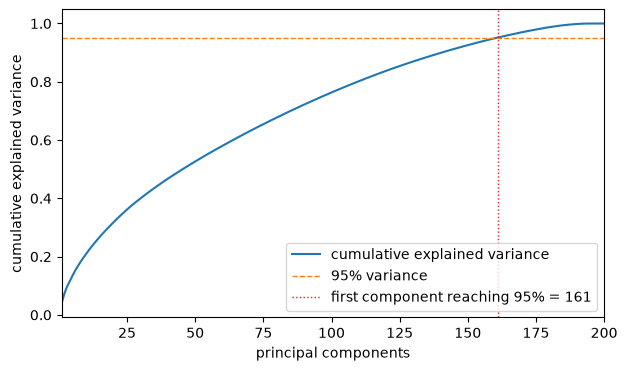

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    range(1, len(cumvar) + 1),
    cumvar,
    linewidth=1.5,
    label="cumulative explained variance",
)
ax.axhline(0.95, color="tab:orange", linestyle="--", linewidth=1, label="95% variance")
ax.axvline(
    n95,
    color="tab:red",
    linestyle=":",
    linewidth=1,
    label=f"first component reaching 95% = {n95}",
)
ax.set_xlabel("principal components")
ax.set_ylabel("cumulative explained variance")
ax.set_xlim(1, len(cumvar))
ax.legend(loc="lower right")
plt.show()

Kurva explained variance kumulatif memotong garis ambang 95% pada komponen
yang sama dengan angka tabel di sel sebelumnya; grafik menjadi bukti visual
pemilihan jumlah komponen dan posisinya terhadap batas 500.

In [22]:
pca_95 = pca.transform(dense_tfidf)[:, :n95].astype("float32")
pca_path = OUT_DIR / "tfidf_pca.npy"
np.save(pca_path, pca_95)
pd.Series(
    {
        "file": "data/Web-Mining/crisp-dm/tfidf_pca.npy",
        "bytes": pca_path.stat().st_size,
        "shape": f"{pca_95.shape[0]} x {pca_95.shape[1]}",
        "variance covered": f"{float(cumvar[n95 - 1]):.2%}",
        "consumed by": "TF-IDF classification arm only",
    },
    name="value",
)

file                data/Web-Mining/crisp-dm/tfidf_pca.npy
bytes                                               128928
shape                                            200 x 161
variance covered                                    95.18%
consumed by                 TF-IDF classification arm only
Name: value, dtype: object

Matriks TF-IDF diproyeksikan ke komponen sekitar ambang 95 persen lalu
disimpan sebagai `tfidf_pca.npy`; lengan yang memakai TF-IDF membaca berkas
ini langsung ketika melatih klasifikasi, sementara lengan skip-gram tidak
memakai reduksi dimensi karena ketentuan word embedding berjalan tanpa PCA.
Ambang, bentuk, dan variance yang tercakup tercatat di keluaran.

## Skip-gram Corpus

Note 2 stops at TF-IDF, PCA, and POS, but the modeling stage trains skip-gram
Word2Vec as the competing representation, so this page also prepares its
training corpus: sentence lists of cleaned, lowercased, slang-normalized
tokens. The corpus keeps natural word forms and function words because
embeddings need context; without-slang, without-stopword, and stemmed
variants stay available as token keys, and the with-punctuation arm reads the
raw column from the crawl CSV.

In [23]:
sentences_by_doc = []
for value in text:
    doc_sentences = []
    for sentence in re.split(r"(?<=[.!?])\s+", value):
        sentence_tokens = []
        for tok in re.findall(r"[A-Za-z0-9]+(?:-[A-Za-z0-9]+)*", sentence):
            if re.fullmatch(r"\d+[xX]\d+", tok):
                sentence_tokens.append(tok.lower())
            elif any(ch.isdigit() for ch in tok) or len(tok) < 2:
                continue
            else:
                tok = tok.lower()
                if tok in protected or replace_slang(tok) == tok:
                    sentence_tokens.append(tok)
                else:
                    sentence_tokens.append(replace_slang(tok))
        if sentence_tokens:
            doc_sentences.append(sentence_tokens)
    sentences_by_doc.append(doc_sentences)
flat_sentences = [tok for doc in sentences_by_doc for sent in doc for tok in sent]
flat_tokens = [tok for doc in tokens for tok in doc]
n_tokens = len(flat_sentences)
n_sentences = sum(len(doc) for doc in sentences_by_doc)
n_docs_corpus = sum(1 for doc in sentences_by_doc if doc)
corpus_vocab = len(set(flat_sentences))
per_sentence = [len(s) for doc in sentences_by_doc for s in doc]
pd.DataFrame(
    [
        {"check": "documents with sentences", "value": n_docs_corpus},
        {"check": "total sentences", "value": n_sentences},
        {"check": "corpus tokens", "value": n_tokens},
        {"check": "unique vocabulary", "value": corpus_vocab},
        {"check": "tokens per sentence, min", "value": min(per_sentence)},
        {
            "check": "tokens per sentence, mean",
            "value": round(sum(per_sentence) / len(per_sentence), 1),
        },
        {"check": "tokens per sentence, max", "value": max(per_sentence)},
        {"check": "matches cleaned token stream", "value": flat_sentences == flat_tokens},
    ]
)

,check,value
0,documents with sentences,200
1,total sentences,4476
2,corpus tokens,70971
3,unique vocabulary,7648
4,"tokens per sentence, min",1
5,"tokens per sentence, mean",15.9
6,"tokens per sentence, max",283
7,matches cleaned token stream,True


Kalimat korpus dipecah dari teks yang sudah dibersihkan lalu melewati
penyaringan, pengecilan huruf, dan normalisasi slang yang sama seperti aliran
token utama. Keluaran mengunci jumlah kalimat, token, dan kosakata, serta
mengecek bahwa gabungan semua kalimat persis sama dengan aliran token yang
dipakai tahap lain — bukti bahwa korpus ini adalah representasi yang sama
dalam bentuk kalimat. Stopword dan stem sengaja dipertahankan karena
embedding butuh kata konteks dan bentuk kata asli. Jumlah kalimat di sini menghitung semua kalimat yang menyisakan minimal satu token setelah penyaringan, sehingga tidak bisa dibandingkan langsung dengan 4314 kalimat yang diklasifikasikan bahasa dan yang mensyaratkan minimal empat kata.

## Token Integration

The processed columns are assembled back onto the raw keys, verified, and
written out as the token file consumed by the modeling stage.

In [24]:
prepared = pd.DataFrame(
    {
        "id": raw["id"],
        "label": raw["label"],
        "url": raw["url"],
        "tokens_preslang": [" ".join(doc) for doc in tokens_preslang],
        "tokens_normalized": [" ".join(doc) for doc in tokens],
        "tokens_no_stopword": [" ".join(doc) for doc in tokens_nostop],
        "tokens_stemmed": [" ".join(doc) for doc in tokens_stem],
        "sentences": sentences_by_doc,
        "pos_tags": pos_by_doc,
    }
)
pd.Series(
    {
        "rows": len(prepared),
        "columns": prepared.shape[1],
        "ids match raw": prepared["id"].tolist() == raw["id"].tolist(),
        "label counts": str(prepared["label"].value_counts().to_dict()),
        "empty token rows": int((prepared["tokens_stemmed"] == "").sum()),
        "documents with pos tags": sum(1 for row in prepared["pos_tags"] if row),
        "documents with sentences": sum(1 for doc in sentences_by_doc if doc),
    },
    name="value",
)

rows                                                   200
columns                                                  9
ids match raw                                         True
label counts                {'sport': 100, 'finance': 100}
empty token rows                                         0
documents with pos tags                                200
documents with sentences                               200
Name: value, dtype: object

Tabel final menggabungkan kolom asli dengan empat varian token, struktur
kalimat korpus skip-gram, dan anotasi POS sebagai kolom pendamping.
Verifikasi mengunci jumlah baris, kecocokan id dengan CSV asli, keseimbangan
label, ketiadaan baris token kosong, serta kelengkapan anotasi dan korpus per
dokumen.

In [25]:
payload = {
    "id": prepared["id"].tolist(),
    "tokens_preslang": prepared["tokens_preslang"].tolist(),
    "tokens_normalized": prepared["tokens_normalized"].tolist(),
    "tokens_no_stopword": prepared["tokens_no_stopword"].tolist(),
    "tokens_stemmed": prepared["tokens_stemmed"].tolist(),
    "sentences": prepared["sentences"].tolist(),
    "pos_tags": prepared["pos_tags"].tolist(),
}
tokens_path = OUT_DIR / "tokens.json"
tokens_path.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
pd.Series(
    {
        "file": "data/Web-Mining/crisp-dm/tokens.json",
        "bytes": tokens_path.stat().st_size,
        "keys": ", ".join(payload),
        "documents": len(payload["id"]),
    },
    name="value",
)

file                      data/Web-Mining/crisp-dm/tokens.json
bytes                                                  4300780
keys         id, tokens_preslang, tokens_normalized, tokens...
documents                                                  200
Name: value, dtype: object

`tokens.json` menyimpan empat varian token, korpus kalimat untuk skip-gram,
dan anotasi POS dengan id yang sejajar dengan CSV — berkas inilah yang nanti
dikonsumsi tahap pemodelan skip-gram maupun TF-IDF. Kunci berkas dan
ukurannya dibaca kembali setelah penulisan sebagai bukti bahwa artefak
benar-benar tertulis.

## Findings

The mapping below ties every preparation step to the Data Understanding row
that triggered it, with before-and-after evidence computed on this page. The two closing rows map the modeling inputs that
Note 2 does not enumerate: the skip-gram corpus and the integrated token file.

In [26]:
non_ascii_now = int(text.map(lambda t: any(ord(c) > 127 for c in t)).sum())
tfidf_terms = tfidf_matrix.shape[1]
findings = pd.DataFrame(
    [
        {
            "preparation step": "Load and verify",
            "data understanding row": "Missing values / Label balance / Duplicate rows and urls / Label versus url host",
            "evidence": f"{len(raw)} rows, {int(raw.isna().sum().sum())} missing cells, {int(raw['url'].duplicated().sum())} duplicate urls",
            "outcome": "no rows dropped",
        },
        {
            "preparation step": "Encoding to ASCII",
            "data understanding row": "Non-ASCII glyphs / Accent marks",
            "evidence": f"{ascii_docs_before} to {non_ascii_now} docs outside ASCII, {glyphs_before} glyphs removed",
            "outcome": "accents decomposed, symbols dropped",
        },
        {
            "preparation step": "Format artifacts",
            "data understanding row": "Table and list remnants / Embedded urls",
            "evidence": f"pipes {before_counts['table pipes']} to {after_counts['table pipes']} docs, urls {before_counts['embedded urls']} to {after_counts['embedded urls']} docs",
            "outcome": "stripped before tokenization",
        },
        {
            "preparation step": "Whitespace collapse",
            "data understanding row": "Newline and space runs",
            "evidence": f"line breaks {line_break_docs} to 0 docs, space runs {space_run_docs} to 0 docs",
            "outcome": "single-space text",
        },
        {
            "preparation step": "Number decisions",
            "data understanding row": "Number artifacts",
            "evidence": f"{date_spans_removed} date spans, {hyphen_removed} hyphen numerics dropped, {rp_before} currency amounts kept as rp",
            "outcome": "digits never counted as terms",
        },
        {
            "preparation step": "Short-token filter",
            "data understanding row": "Single-character residue / Short tokens",
            "evidence": f"{dropped_single} single-character dropped, {dropped_digit} digit-bearing dropped, two-character kept",
            "outcome": "minimum length two",
        },
        {
            "preparation step": "Language policy",
            "data understanding row": "Sentence languages / Token language candidates",
            "evidence": f"{non_id} of {sum(sentence_langs.values())} sentences outside id/ms, {en_labels} of 400 token labels unreliable, 0 translations",
            "outcome": "preserve-first",
        },
        {
            "preparation step": "Name protection",
            "data understanding row": "Mixed-case name candidates",
            "evidence": f"{len(protected)} protected tokens from cap-mid and all-caps evidence",
            "outcome": "blocked from slang and stemmer",
        },
        {
            "preparation step": "Slang normalization",
            "data understanding row": "Slang candidates",
            "evidence": f"{sum(slang_hits.values())} dictionary hits, {replaced} normalized, {protected_seen} protected occurrences kept",
            "outcome": "context-checked replacement only",
        },
        {
            "preparation step": "POS annotation",
            "data understanding row": "Preprocessing Pipeline step 10",
            "evidence": f"{n_tagged} tokens tagged across {len(tag_counts)} tag categories, before stopword removal",
            "outcome": "auxiliary column only",
        },
        {
            "preparation step": "Stopword removal",
            "data understanding row": "Stopword share",
            "evidence": f"{sw_removed} of {tokens_before_stopword} tokens removed ({round(100 * sw_removed / tokens_before_stopword, 1)}%)",
            "outcome": "after POS annotation",
        },
        {
            "preparation step": "Stemming with guard",
            "data understanding row": "Elongated words",
            "evidence": f"{stem_changes} stem changes, {protected_skipped} protected tokens skipped",
            "outcome": "acronyms and names intact",
        },
        {
            "preparation step": "Unique words",
            "data understanding row": "Preprocessing Pipeline step 7",
            "evidence": f"vocabulary size {vocab_size} via scikit-learn",
            "outcome": "per-doc unique counts above",
        },
        {
            "preparation step": "TF-IDF dataset",
            "data understanding row": "Preprocessing Pipeline step 8",
            "evidence": f"sparse {tfidf_shape} with {int(tfidf_matrix.nnz)} stored weights",
            "outcome": "saved as npz plus feature and doc lists",
        },
        {
            "preparation step": "PCA summary",
            "data understanding row": "Preprocessing Pipeline step 9",
            "evidence": f"{n95} components reach 95% variance, {len(cumvar)} available in total",
            "outcome": "all thresholds below 500",
        },
        {
            "preparation step": "Skip-gram corpus",
            "data understanding row": "Note 4/5 modeling prerequisite (outside Note 2)",
            "evidence": f"{n_sentences} sentences, {n_tokens} tokens, vocabulary {corpus_vocab}",
            "outcome": "sentence lists stored per document",
        },
        {
            "preparation step": "Token integration",
            "data understanding row": "Corpus structure / Label balance",
            "evidence": f"tokens.json 7 keys across {len(prepared)} docs, tfidf_pca.npy {pca_95.shape}",
            "outcome": "all modeling inputs in one folder",
        },

    ]
)
findings

,preparation step,data understanding row,evidence,outcome
0,Load and verify,Missing values / Label balance / Duplicate row...,"200 rows, 0 missing cells, 0 duplicate urls",no rows dropped
1,Encoding to ASCII,Non-ASCII glyphs / Accent marks,"6 to 0 docs outside ASCII, 8 glyphs removed","accents decomposed, symbols dropped"
2,Format artifacts,Table and list remnants / Embedded urls,"pipes 37 to 0 docs, urls 2 to 0 docs",stripped before tokenization
3,Whitespace collapse,Newline and space runs,"line breaks 200 to 0 docs, space runs 41 to 0 ...",single-space text
4,Number decisions,Number artifacts,"164 date spans, 55 hyphen numerics dropped, 72...",digits never counted as terms
5,Short-token filter,Single-character residue / Short tokens,"218 single-character dropped, 3772 digit-beari...",minimum length two
6,Language policy,Sentence languages / Token language candidates,"109 of 4314 sentences outside id/ms, 253 of 40...",preserve-first
7,Name protection,Mixed-case name candidates,1274 protected tokens from cap-mid and all-cap...,blocked from slang and stemmer
8,Slang normalization,Slang candidates,"311 dictionary hits, 161 normalized, 35654 pro...",context-checked replacement only
9,POS annotation,Preprocessing Pipeline step 10,"100051 tokens tagged across 26 tag categories,...",auxiliary column only


Sel ini merangkum seluruh tahap menjadi satu tabel pemetaan: setiap baris
persiapan menunjuk baris temuan atau langkah pipeline di halaman pemahaman
data, lengkap dengan bukti sebelum-sesudah dari eksekusi halaman ini. Lima
belas baris pertama mengikuti sepuluh langkah pipeline; dua baris pamungkas
menunjuk ke depan ke kebutuhan pemodelan — korpus skip-gram dan artefak
token yang terintegrasi — karena Note 2 tidak mensyaratkan keduanya.

### Takeaways

Korpus lolos verifikasi tanpa baris yang hilang: 200 artikel (100 sport, 100
finance), nol sel kosong, nol duplikat baris atau URL, id berurutan, dan
seluruh host cocok dengan label. Normalisasi ASCII memetakan 6 dokumen dengan
8 glyph di luar ASCII dan 3 aksen menjadi nol; pemotongan artefak menghapus
penanda tabel dari 37 dokumen, sisipan list atau heading dari 17 dokumen,
mention dari 4 dokumen, dan tautan dari 2 dokumen; pelipatan whitespace
mengubah 200 dokumen multiline menjadi satu baris spasi tunggal dengan jumlah
karakter turun dari 538307 ke 537514. Hitungan list dan ruang beruntun naik
sedikit dari angka teks mentah di temuan (16 ke 17 dan 1 ke 41) karena
normalisasi dan pemotongan membuka penanda serta jarak yang sebelumnya
tersembunyi — selisih yang tercatat dan dijelaskan di seksi cleaning, bukan
kebetulan.

Keputusan angka berjalan per kelas dengan tabel konteksnya sendiri: 164
potongan tanggal dibuang, 72 nominal dipangkas menjadi `rp`, 55 kode
ber-angka hilang di tingkat teks, dan 85 komposit skor dipertahankan utuh
sehingga aliran 74961 token tidak pernah menyisakan residu `x`. Penyaringan
token lalu membuang 218 token satu huruf dan 3772 token berangka ke angka
70971, dengan tiga kelas temuan tetap terbaca di tabel: 1143 token satu
huruf, 3804 token dua huruf, dan 3857 token berangka, masing-masing dengan
keputusan drop atau keep.

Kebijakan bahasa preserve-first terkunci oleh 4314 kalimat yang
diklasifikasikan dengan 109 di luar id/ms dan 253 dari 400 token teratas
salah berlabel `en`; nol token diterjemahkan dan baris nol itu sendiri
menjadi bagian dari tabel keputusan. Anotasi POS berjalan sebelum stopword:
100051 token ditandai 26 kategori (NNP 27735, NNO 21463, SYM 11589) oleh
model publik — satu-satunya akses jaringan halaman — dan disimpan sebagai
kolom pendamping, bukan bagian dari representasi akhir. Stopword Sastrawi
membuang 16907 dari 70971 token (23.8%), stemming mengubah 13672 token
sementara 24220 token terlindungi dilewati; daftar perlindungan berisi 1274
token kandidat nama dan akronim yang diblokir dari slang maupun stemmer. Dari
311 kemunculan kandidat kamus slang terbukti 161 penggantian diterapkan,
sementara 35654 kemunculan token terlindungi dilewat tanpa sentuhan kamus.

Tahap transformasi menuntaskan representasi siap model: kosakata berisi 5431
kata unik dengan rata-rata 149.1 kata unik per dokumen, dan TF-IDF sparse
200 x 5431 dengan 29818 bobot tersimpan (kepadatan 2.75%) ditulis sebagai
`tfidf.npz`, `tfidf_docs.csv`, dan `tfidf_features.txt`. PCA menunjukkan
110, 141, 161, dan 182 komponen pada ambang 80, 90, 95, dan 99 persen —
semuanya di bawah batas 500 — dan proyeksi 200 x 161 pada ambang 95 persen
(variance 95.18%) disimpan sebagai `tfidf_pca.npy` sebesar 128928 byte untuk
lengan TF-IDF pemodelan.

Integrasi mengunci 200 baris dan 9 kolom dengan id yang cocok, keseimbangan
label sport-finance, serta anotasi dan korpus lengkap di seluruh dokumen.
`tokens.json` tertulis 4300780 byte dengan tujuh kunci — empat varian token,
korpus kalimat, dan anotasi POS — sementara korpus skip-gram itu sendiri
berisi 4476 kalimat dengan 70971 token, kosakata 7648, dan rata-rata 15.9
token per kalimat; gabungan semua kalimat persis sama dengan aliran token
yang dipakai tahap lain, sehingga tahap pemodelan melatih Word2Vec skip-gram
langsung dari kunci `sentences` tanpa gerakan data tambahan.

Tabel Findings menutup lingkaran tersebut: ketujuh belas barisnya menautkan
tiap langkah persiapan ke baris temuan atau langkah pipeline yang memicunya,
lengkap dengan bukti sebelum-sesudah dari eksekusi halaman ini — lima belas
baris mengikuti sepuluh langkah pipeline, dua baris pamungkas menunjuk ke
depan ke kebutuhan pemodelan skip-gram dan artefak token yang terintegrasi.

## Conclusion

Tahap data preparation selesai penuh pada 200 artikel yang sama dengan yang
dikumpulkan: tidak ada baris yang dibuang, setiap transformasi menyertakan
bukti sebelum-sesudah, dan setiap keputusan menunjuk temuan Data Understanding
yang memicunya. Representasi siap model kini tersimpan di
`data/Web-Mining/crisp-dm/` — TF-IDF sparse beserta daftar fitur dan label
dokumen, proyeksi PCA 200 x 161 pada 95 persen variance, dan `tokens.json`
dengan empat varian token, korpus kalimat skip-gram, serta anotasi POS —
sementara tag POS, kebijakan bahasa, dan keputusan angka tetap berstatus
pendamping yang tidak pernah mengubah matriks akhir. Dengan ambang PCA
tertinggi 182 komponen pada 99 persen variance, seluruh target reduksi di
bawah 500 terpenuhi; korpus 4476 kalimat siap dipakai Word2Vec tanpa gerakan
tambahan, dan halaman ini menjadi masukan penuh tahap pemodelan.